<a href="https://colab.research.google.com/github/Suraj-Btech/firstcode/blob/main/Iris_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pyspark.sql import SparkSession
from sklearn.datasets import load_iris
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
spark = SparkSession.builder \
    .appName("Iris Data Visualization") \
    .getOrCreate()

In [ ]:
iris_sklearn = load_iris()

In [ ]:
iris_df = pd.DataFrame(data=iris_sklearn.data, columns=iris_sklearn.feature_names)
iris_df['species'] = iris_sklearn.target

In [ ]:
iris_df['species'] = iris_df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

In [ ]:
spark_df = spark.createDataFrame(iris_df)

In [ ]:
spark_df.printSchema()
spark_df.show(5)

root
 |-- sepal length (cm): double (nullable = true)
 |-- sepal width (cm): double (nullable = true)
 |-- petal length (cm): double (nullable = true)
 |-- petal width (cm): double (nullable = true)
 |-- species: string (nullable = true)

+-----------------+----------------+-----------------+----------------+-------+
|sepal length (cm)|sepal width (cm)|petal length (cm)|petal width (cm)|species|
+-----------------+----------------+-----------------+----------------+-------+
|              5.1|             3.5|              1.4|             0.2| setosa|
|              4.9|             3.0|              1.4|             0.2| setosa|
|              4.7|             3.2|              1.3|             0.2| setosa|
|              4.6|             3.1|              1.5|             0.2| setosa|
|              5.0|             3.6|              1.4|             0.2| setosa|
+-----------------+----------------+-----------------+----------------+-------+
only showing top 5 rows



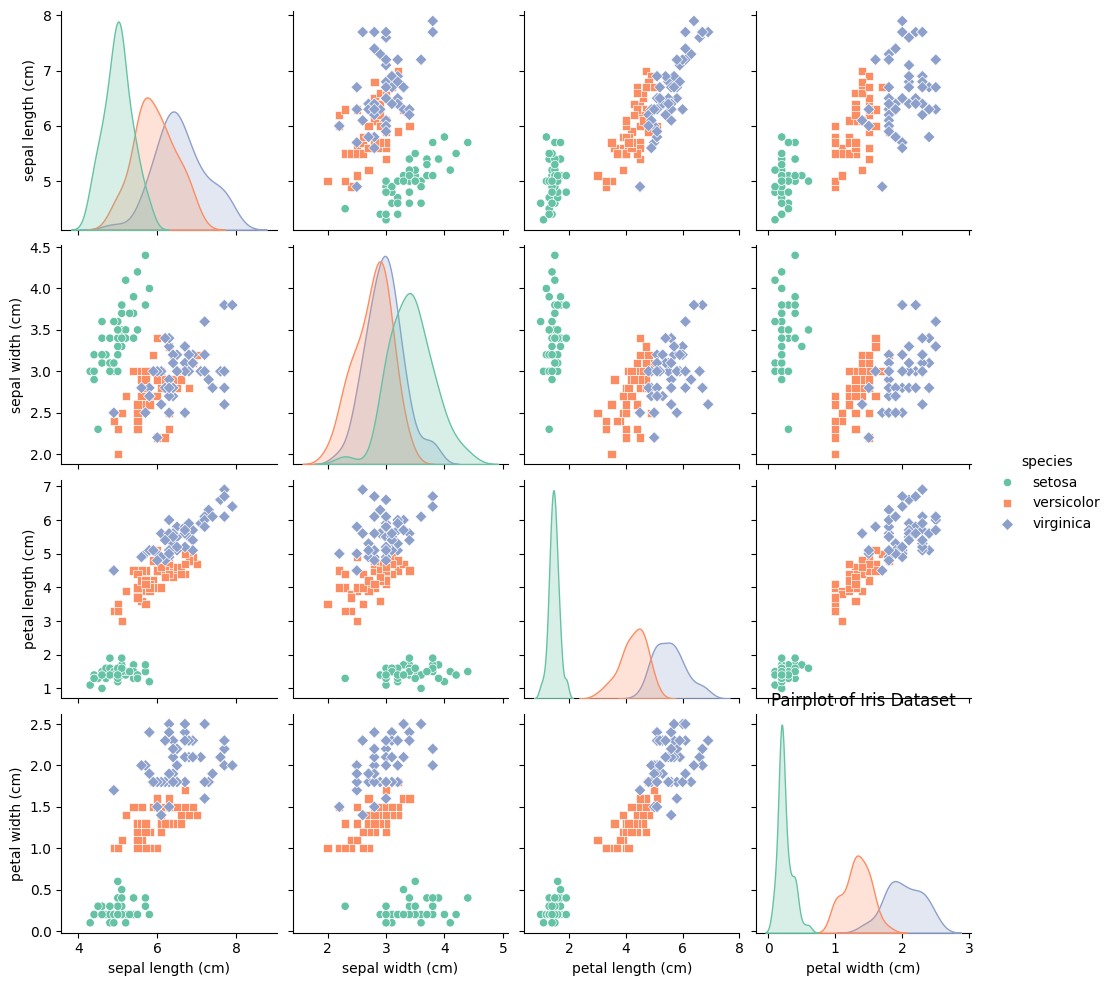

In [ ]:
sns.pairplot(iris_df, hue="species", markers=["o", "s", "D"], palette="Set2")
plt.title("Pairplot of Iris Dataset")
plt.show()

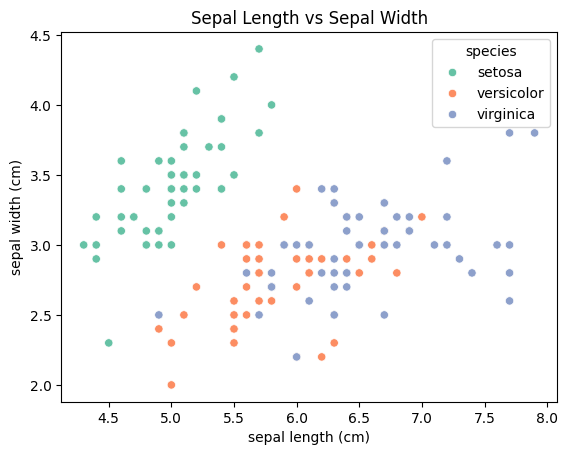

In [ ]:
sns.scatterplot(x="sepal length (cm)", y="sepal width (cm)", hue="species", data=iris_df, palette="Set2")
plt.title("Sepal Length vs Sepal Width")
plt.show()

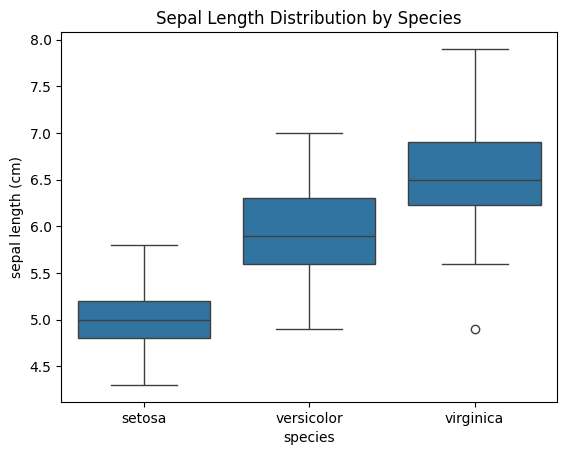

In [ ]:
sns.boxplot(x="species", y="sepal length (cm)", data=iris_df)
plt.title("Sepal Length Distribution by Species")
plt.show()

In [ ]:
spark.stop()
